<div style="border-left:5px solid #2a78d6;padding:6px 0 6px 20px;margin-bottom:6px">

# AeroTrack-Net
## Detecting 9-pixel drones in thermal and visible video

**Review 1 — Dataset Inspection, Spatio-Temporal Analysis & Architectural Justification**

</div>

> ### We did not choose an architecture and then look for data.
> ### We measured **723,675 bounding boxes**, and the measurements dictated the architecture.

---

**How to run:** execute cells top-to-bottom. Every table and figure in this notebook is
regenerated **live** from the analysis artifacts on disk — nothing is pre-rendered.

**Use the project `venv` kernel** (`venv/Scripts/python.exe`). The `.pkl` artifacts were
written by the venv's pandas and are version-coupled.

---
## Setup — identity, palette, helpers

A single locked palette is used by every figure *and* every table, so the deck reads as one
designed system. Colours are CVD-safe.

In [69]:
import json, pickle, sys, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from IPython.display import HTML, display

warnings.filterwarnings("ignore")

# ── locate project root (walk upward until a_inspection/ appears) ─────────
ROOT = Path.cwd()
for _ in range(5):
    if (ROOT / "a_inspection").is_dir():
        break
    ROOT = ROOT.parent
else:
    raise SystemExit("Could not find project root containing a_inspection/")

ART = ROOT / "a_inspection" / "artifacts"
UNI = ROOT / "b_pipeline" / "data_unified"

# ── locked identity ──────────────────────────────────────────────────────
DS_ORDER = ["anti_uav", "cst_anti_uav", "det_fly"]
DS_LABEL = {"anti_uav": "Anti-UAV", "cst_anti_uav": "CST Anti-UAV", "det_fly": "Det-Fly"}
DS_COLOR = {"anti_uav": "#2a78d6", "cst_anti_uav": "#008300", "det_fly": "#eda100"}

# High-contrast, THEME-PROOF palette. Every custom block paints its own light
# surface and dark ink, so the deck reads identically under a dark Jupyter
# theme, a light one, or exported to PDF.
INK    = "#0f1114"          # primary text        — 18.9:1 on the card
MUTED  = "#3f444c"          # secondary text      —  9.7:1 on the card
SURF   = "#fcfcfb"          # card / figure surface
CARD   = "#f1f1ec"          # table header / inset panels
LINE   = "#c4c4be"
ACCENT = "#a3271a"          # 6.4:1 on the card

# Darkened ink variants of the dataset hues for TEXT and big numbers.
# (Raw #eda100 amber is only ~1.9:1 on white — unusable as type.)
DS_INK = {"anti_uav": "#17549e", "cst_anti_uav": "#00631a", "det_fly": "#7d5000"}
_SAFE  = {DS_COLOR[k]: DS_INK[k] for k in DS_COLOR}

mpl.rcParams.update({
    "figure.facecolor": SURF, "axes.facecolor": SURF, "savefig.facecolor": SURF,
    "figure.dpi": 110, "font.size": 11,
    "axes.edgecolor": "#b8b8b2", "axes.labelcolor": INK, "text.color": INK,
    "xtick.color": MUTED, "ytick.color": MUTED,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": "#dededa", "grid.linewidth": 0.8,
    "legend.frameon": False, "figure.autolayout": False,
})

# ── display helpers ──────────────────────────────────────────────────────
_CARDBOX = ("background:%s;border:1px solid %s;border-radius:10px;" % (SURF, LINE))

def hero(items, caption=None):
    """items: list of (value, label, colour) -> big-number strip."""
    cells = "".join(
        "<div style='flex:1;min-width:145px;padding:14px 18px'>"
        "<div style='font-size:32px;font-weight:800;color:%s;line-height:1.05'>%s</div>"
        "<div style='font-size:12px;color:%s;margin-top:7px;line-height:1.4'>%s</div></div>"
        % (_SAFE.get(c, c), v, MUTED, l) for v, l, c in items)
    cap = ("<div style='font-size:12px;color:%s;padding:2px 18px 13px'>%s</div>"
           % (MUTED, caption)) if caption else ""
    display(HTML("<div style='%spadding:4px 0;margin:10px 0'>"
                 "<div style='display:flex;flex-wrap:wrap'>%s</div>%s</div>"
                 % (_CARDBOX, cells, cap)))

def title(text, kicker=None):
    """Section heading. Paints its own surface so it survives a dark theme."""
    k = ("<div style='font-size:11.5px;letter-spacing:.10em;text-transform:uppercase;"
         "font-weight:700;color:%s;margin-bottom:5px'>%s</div>" % (ACCENT, kicker)) if kicker else ""
    display(HTML("<div style='%spadding:13px 18px;margin:22px 0 8px;border-left:5px solid %s'>"
                 "%s<div style='font-size:18px;font-weight:800;color:%s;line-height:1.3'>%s</div>"
                 "</div>" % (_CARDBOX, INK, k, INK, text)))

def panel(html, accent=None):
    """Inset commentary block — always light surface, always dark ink."""
    display(HTML("<div style='background:%s;border:1px solid %s;border-left:4px solid %s;"
                 "border-radius:0 8px 8px 0;padding:14px 18px;margin:10px 0 16px;"
                 "font-size:13px;line-height:1.7;color:%s'>%s</div>"
                 % (SURF, LINE, accent or INK, INK, html)))

def table(df, note=None):
    sty = (df.style.hide(axis="index")
           .set_table_styles([
               {"selector": "th", "props": [("background", CARD), ("font-size", "12px"),
                                            ("text-align", "left"), ("padding", "8px 12px"),
                                            ("border-bottom", "2px solid %s" % LINE),
                                            ("color", INK), ("font-weight", "700")]},
               {"selector": "td", "props": [("padding", "7px 12px"), ("font-size", "13px"),
                                            ("background", SURF), ("color", INK),
                                            ("border-bottom", "1px solid #e4e4de")]},
               {"selector": "", "props": [("border-collapse", "collapse"),
                                          ("border", "1px solid %s" % LINE),
                                          ("border-radius", "8px"), ("overflow", "hidden"),
                                          ("margin", "6px 0")]},
           ]))
    display(sty)
    if note:
        display(HTML("<div style='background:%s;border:1px solid %s;border-radius:8px;"
                     "padding:11px 15px;font-size:12.5px;color:%s;margin:6px 0 16px;"
                     "line-height:1.65'>%s</div>" % (CARD, LINE, MUTED, note)))

def finish(fig, t, sub=None):
    """Title + subtitle above the axes.

    Space is reserved in ABSOLUTE INCHES and then converted to a figure
    fraction, so the header never collides with the axes regardless of how
    short the figure is. (Fixed fractional offsets break on short figures:
    0.05 of a 2.9in figure is only ~10pt — less than the title's own height.)
    """
    H = fig.get_size_inches()[1]
    pad, t_h, s_h = 0.09, 0.30, (0.25 if sub else 0.0)
    fig.suptitle(t, fontsize=13.5, fontweight="bold",
                 x=0.012, y=1 - pad / H, ha="left", va="top")
    if sub:
        fig.text(0.012, 1 - (pad + t_h) / H, sub,
                 fontsize=10.5, color=MUTED, ha="left", va="top")
    fig.tight_layout(rect=[0, 0, 1, 1 - (pad + t_h + s_h) / H])
    plt.show()

print("project root :", ROOT)
print("python       :", sys.version.split()[0], "| pandas", pd.__version__, "| numpy", np.__version__)

project root : d:\Drone_Maxxing
python       : 3.13.7 | pandas 3.0.5 | numpy 2.5.1


In [70]:
# ── load every analysis artifact ─────────────────────────────────────────
def _json(p):
    return json.loads(Path(p).read_text(encoding="utf-8"))

def _pkl(name):
    with open(ART / name, "rb") as f:
        return pickle.load(f)

basic   = _json(ART / "basic_eda.json")
track   = _json(ART / "tracking_metrics.json")
xfact   = _json(ART / "xfactor_analysis.json")
extract = _json(ART / "extraction_summary.json")
stdsum  = _json(UNI / "standardization_summary.json")

media = pd.read_csv(ART / "media_meta.csv")
try:
    bboxes = _pkl("bboxes.pkl")
    vel    = _pkl("velocities.pkl")
    spdsc  = _pkl("speed_scale.pkl")
    blur   = _pkl("blur_samples.pkl")
except Exception as e:
    raise SystemExit(
        "Failed to unpickle artifacts (%r).\\n"
        "These were written by the venv's pandas — switch this notebook's kernel to "
        "venv/Scripts/python.exe and re-run." % (e,))
heat = np.load(ART / "heatmaps.npz")

print(f"media_meta.csv  {len(media):>10,} rows")
print(f"bboxes.pkl      {len(bboxes):>10,} boxes")
print(f"velocities.pkl  {len(vel):>10,} frame-to-frame transitions")
print(f"speed_scale.pkl {len(spdsc):>10,} (speed, area) pairs")
print(f"blur_samples    {len(blur):>10,} decoded ROIs")
print(f"heatmaps.npz    {list(heat.keys())}")

media_meta.csv       8,610 rows
bboxes.pkl         723,675 boxes
velocities.pkl     706,147 frame-to-frame transitions
speed_scale.pkl    706,147 (speed, area) pairs
blur_samples         3,588 decoded ROIs
heatmaps.npz    ['anti_uav', 'cst_anti_uav', 'det_fly']


---
<div style="background:#f2f6fc;border-left:5px solid #2a78d6;padding:14px 20px;border-radius:0 8px 8px 0;color:#0f1114">

# ACT I · The Threat
### What makes counter-UAS vision genuinely hard

</div>

A drone at operational range is not a "small object" in the COCO sense. It is a handful of pixels,
moving erratically, that periodically disappears — and it has to be told apart from a bird.

Every number on the next screen was measured from our own corpus, before any model was designed.

In [71]:
title("Four properties that break a standard detector", kicker="Act I · the threat")

sa   = track["scale_and_aspect"]
vmax = max(v["speed_px_per_frame"]["max"] for v in track["velocity"].values())
oov  = xfact["autonomous_findings"]["occlusion_out_of_view"]
oovmax  = max(v["max_oov_event_len"] for v in oov.values())
cls  = basic["modalities_classes"]["det_fly"]["class_histogram"]

med_cst   = sa["cst_anti_uav"]["relative_area"]["median"]
micro_cst = sa["cst_anti_uav"]["micro_visibility_ratio_lt_0.03pct"]
px_cst    = (med_cst * 640 * 512) ** 0.5     # equivalent square side at CST resolution

hero([
    (f"{med_cst*100:.3f}%",        f"median target area (CST) &mdash; a {px_cst:.0f}&times;{px_cst:.0f} px square", DS_COLOR["cst_anti_uav"]),
    (f"{micro_cst*100:.1f}%",      "of targets are <b>micro</b> (&lt;0.03% of frame)",                              DS_COLOR["cst_anti_uav"]),
    (f"{vmax:,.0f} px",            "largest displacement in a <b>single frame</b>",                                  DS_COLOR["anti_uav"]),
    (f"{oovmax}",                  "longest <b>out-of-view</b> gap (frames)",                                        ACCENT),
    (f"{cls['Bird']:,}:{cls['Drone']:,}", "birds : drones in the wild &mdash; the false-positive trap",              DS_COLOR["det_fly"]),
], caption="All values measured across 723,675 annotated boxes / 763,819 frames. Nothing here is an estimate.")

panel(f"<span style='font-size:15px'>A standard detector discards <b>3 of every 4 pixels</b> at "
      f"each downsampling stage &mdash; before it has looked at them. "
      f"On a {px_cst:.0f}&times;{px_cst:.0f} px target, that is fatal.</span>", ACCENT)

---
<div style="background:#f2fbf3;border-left:5px solid #008300;padding:14px 20px;border-radius:0 8px 8px 0;color:#0f1114">

# ACT II · The Data
### Three datasets, chosen for sensor coverage — not convenience

</div>

A deployable counter-UAS system must work **at night**. That single requirement drives the dataset
selection: we need thermal (IR), we need visible (RGB), and we need them **paired on the same
scenes** so the choice can be justified with evidence rather than assertion.

In [72]:
title("Sensor-coverage matrix", kicker="Act II · the data")

mod = pd.DataFrame([
    ["Anti-UAV",     "Yes  640x512",  "Yes  1920x1080", "The bridge — 1:1 paired IR↔RGB, enables true modality ablation"],
    ["CST Anti-UAV", "Yes  640x512",  "No",            "The stress test — hardest targets, highest micro share"],
    ["Det-Fly",      "No",            "Yes  640x640",   "The FP suppressor — bird hard negatives"],
], columns=["Dataset", "Thermal (IR)", "Visible (RGB)", "Role in the design"])
table(mod, note="Together the three cover the full day/night operating envelope. One backbone, "
                "trained across both modalities, yields one deployable model.")

# live modality / frame counts straight from the master index
rows = []
for dk in DS_ORDER:
    g = media[media.dataset == dk]
    mods = g.groupby("modality").size().to_dict()
    rows.append([DS_LABEL[dk], f"{len(g):,}",
                 ", ".join(f"{k}: {v:,}" for k, v in sorted(mods.items())),
                 f"{int(g['n_frames_ann'].fillna(0).sum()):,}"])
table(pd.DataFrame(rows, columns=["Dataset", "Media items", "Modality split (media)", "Annotated frames"]),
      note="Anti-UAV ships every sequence twice — once thermal, once visible — which is what makes "
           "the controlled IR-vs-RGB comparison later in this notebook possible.")

Dataset,Thermal (IR),Visible (RGB),Role in the design
Anti-UAV,Yes 640x512,Yes 1920x1080,"The bridge — 1:1 paired IR↔RGB, enables true modality ablation"
CST Anti-UAV,Yes 640x512,No,"The stress test — hardest targets, highest micro share"
Det-Fly,No,Yes 640x640,The FP suppressor — bird hard negatives


Dataset,Media items,Modality split (media),Annotated frames
Anti-UAV,636,"IR: 318, RGB: 318","593,802"
CST Anti-UAV,144,IR: 144,"162,187"
Det-Fly,"7,830","RGB: 7,830","15,969"


In [73]:
title("CST Anti-UAV — forward streaming recovery", kicker="Act II · data engineering")

c = extract["datasets"]["cst_anti_uav"]
gb = lambda b: f"{b/1024**3:.2f} GiB"
hero([
    (f"{c['files']:,}",   "files recovered from a headless archive", DS_COLOR["cst_anti_uav"]),
    (f"{c['crc_ok']:,}",  "CRC-32 verified <b>correct</b>",          DS_COLOR["cst_anti_uav"]),
    (f"{c['crc_bad']}",   "CRC failures",                            INK),
    (gb(c["bytes_read"]), "of stream walked header-by-header",       MUTED),
    (f"{c['seconds']/60:.0f} min", "recovery runtime",                MUTED),
])
table(pd.DataFrame([
    ["Volumes delivered",  ", ".join(c["volumes"])],
    ["Volume missing",     "CST-AntiUAV.zip  (End-Of-Central-Directory + central directory)"],
    ["Standard tools",     "unzip / 7-Zip / Python zipfile — all fail: they seek EOCD first"],
    ["Method",             "Chain volumes → walk PK\\x03\\x04 local headers → inflate per member"],
    ["Precondition",       "No data descriptors (GP bit 3 = 0) → header sizes authoritative"],
    ["Terminated at",      c["truncated_member"] or "—"],
], columns=["", "Detail"]),
 note="The stream truncated exactly where predicted — mid-file, inside the last member of volume 7. "
      "The partial file was <b>deleted</b> rather than left to silently corrupt downstream parsing. "
      "144 usable sequences survived.")

,Detail
Volumes delivered,"CST-AntiUAV.z01, CST-AntiUAV.z02, CST-AntiUAV.z03, CST-AntiUAV.z04, CST-AntiUAV.z05, CST-AntiUAV.z06, CST-AntiUAV.z07"
Volume missing,CST-AntiUAV.zip (End-Of-Central-Directory + central directory)
Standard tools,unzip / 7-Zip / Python zipfile — all fail: they seek EOCD first
Method,Chain volumes → walk PK\x03\x04 local headers → inflate per member
Precondition,No data descriptors (GP bit 3 = 0) → header sizes authoritative
Terminated at,CST-AntiUAV/CST-AntiUAV/train/urban-areas_1/000657.jpg


### Corpus scale

Read the *Missing-annotation* column carefully — it is the single most misread number in this study.

In [74]:
title("Frames, annotations, and what 'missing' actually means", kicker="Act II · scale")

rows = []
for dk in DS_ORDER:
    v = basic["frame_counts"][dk]
    rows.append([DS_LABEL[dk], f"{v['n_sequences_or_images']:,}", f"{v['total_frames']:,}",
                 f"{v['annotated_frames']:,}", f"{v['empty_frames']:,}",
                 f"{v['missing_annotation_ratio']*100:.1f}%"])
tot = basic["grand_totals"]
rows.append(["TOTAL", f"{tot['total_media']:,}", f"{tot['total_frames']:,}",
             "—", "—", "—"])
table(pd.DataFrame(rows, columns=["Dataset", "Seqs / Images", "Frames", "Annotated",
                                  "Empty (no target)", "Missing-ann"]),
      note="<b>The 16.9% is not missing data — it is the occlusion label.</b> Those are frames where "
           "<code>exist = 0</code>: the drone is genuinely out of view or fully occluded. We keep them as "
           "0-byte label files, which turns an apparent defect into the supervision signal for "
           "occlusion-robust tracking (see Act IV, ByteTrack).")

Dataset,Seqs / Images,Frames,Annotated,Empty (no target),Missing-ann
Anti-UAV,636,"593,802","573,427","20,375",3.4%
CST Anti-UAV,144,"162,187","134,724","27,463",16.9%
Det-Fly,"7,830","7,830","7,830",0,0.0%
TOTAL,"8,610","763,819",—,—,—


Dataset,Distinct resolutions,Resolutions (media count)
Anti-UAV,2,"640x512 (318), 1920x1080 (318)"
CST Anti-UAV,1,640x512 (144)
Det-Fly,1,"640x640 (7,830)"


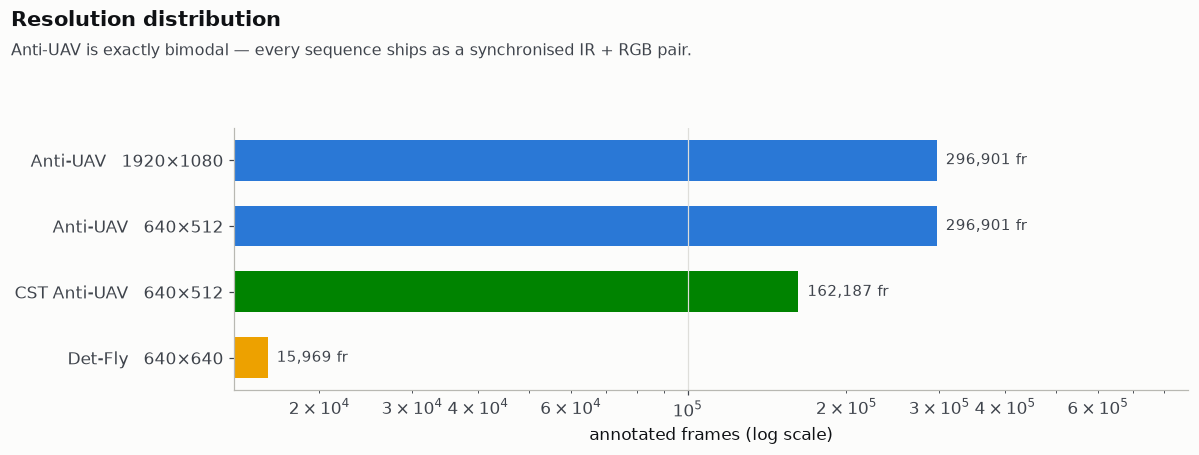

In [75]:
title("Resolution — everything converges on ~640 px, except one stream", kicker="Act II · resolution")

rows = []
for dk in DS_ORDER:
    r = basic["resolution"][dk]
    top = ", ".join(f"{k} ({v:,})" for k, v in list(r["resolutions_by_media"].items())[:3])
    rows.append([DS_LABEL[dk], r["distinct_resolutions"], top])
table(pd.DataFrame(rows, columns=["Dataset", "Distinct resolutions", "Resolutions (media count)"]))

# ── figure: annotated frames per (dataset, resolution) ───────────────────
agg = (media.assign(res=media.width.astype(int).astype(str) + "×" + media.height.astype(int).astype(str))
            .groupby(["dataset", "res"], as_index=False)["n_frames_ann"].sum()
            .query("n_frames_ann > 0")
            .sort_values("n_frames_ann"))
fig, ax = plt.subplots(figsize=(11, 4.2))
labels = [f"{DS_LABEL[d]}   {r}" for d, r in zip(agg.dataset, agg.res)]
ax.barh(labels, agg.n_frames_ann, color=[DS_COLOR[d] for d in agg.dataset], height=.62)
for y, (n, d) in enumerate(zip(agg.n_frames_ann, agg.dataset)):
    ax.text(n * 1.04, y, f"{int(n):,} fr", va="center", fontsize=10, color=MUTED)
ax.set_xscale("log"); ax.set_xlim(right=agg.n_frames_ann.max() * 3)
ax.set_xlabel("annotated frames (log scale)"); ax.grid(axis="y", visible=False)
finish(fig, "Resolution distribution",
       "Anti-UAV is exactly bimodal — every sequence ships as a synchronised IR + RGB pair.")

panel("<b>Three inferences, all actionable:</b><br>"
      "1. Two of three datasets are natively ~640 px &rarr; a <b>640&times;640 network input is native, "
      "not a compromise</b>.<br>"
      "2. Anti-UAV pairs IR&harr;RGB <b>1:1</b> &rarr; we can ablate modality on identical scenes.<br>"
      "3. <b>Known cost, stated plainly:</b> 1920&times;1080 &rarr; 640 loses 3&times; linear resolution; "
      "a 20 px drone becomes 6.7 px. Resolution-preserving tiling for the RGB stream is our identified "
      "next optimisation.", DS_INK["anti_uav"])

In [76]:
title("Annotation integrity", kicker="Act II · integrity")

rows = []
for dk in DS_ORDER:
    v = basic["integrity"][dk]
    rows.append([DS_LABEL[dk], f"{v['total_bboxes']:,}", f"{v['oob_total']:,}",
                 f"{v['oob_ratio']*100:.3f}%", f"{v['degenerate_boxes_<=1px']:,}",
                 v["corrupt_media"]])
table(pd.DataFrame(rows, columns=["Dataset", "Total boxes", "Out-of-bounds", "OOB ratio",
                                  "Degenerate ≤1 px", "Corrupt media"]),
      note="Handling: clip box to frame → reject any box whose clipped width or height is ≤ 0 → "
           "<code>clamp01</code> every normalised coordinate. A post-conversion audit of 1,000 random "
           "label files found <b>zero</b> out-of-bounds coordinates.")

panel("<b>Two discrepancies that look like bugs and are not &mdash; we audited our own numbers:</b><br>"
      "&bull; Anti-UAV reports 573,427 annotated but 572,982 boxes. The 445-frame gap is frames flagged "
      "<code>exist=1</code> carrying an invalid or degenerate rect; they correctly fall through to "
      "&lsquo;empty&rsquo;.<br>"
      "&bull; Det-Fly reports 0 background images yet only 7,345 / 7,830 have a UAV target. The 485 "
      "difference is images containing <b>only birds</b>. Both statements are true &mdash; they measure "
      "different things.")

Dataset,Total boxes,Out-of-bounds,OOB ratio,Degenerate ≤1 px,Corrupt media
Anti-UAV,"572,982",0,0.000%,10,0
CST Anti-UAV,"134,724",7,0.005%,0,0
Det-Fly,"15,969",0,0.000%,0,0


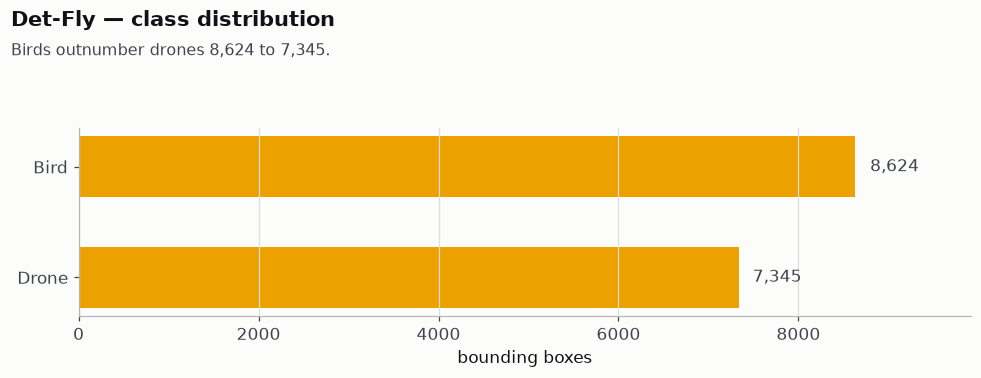

In [77]:
title("Class composition — birds are the majority class", kicker="Act II · classes")

d = bboxes[bboxes.dataset == "det_fly"]
cc = d.class_name.value_counts()
fig, ax = plt.subplots(figsize=(9, 3.5))
ax.barh(cc.index[::-1], cc.values[::-1], color=DS_COLOR["det_fly"], height=.55)
for y, v in enumerate(cc.values[::-1]):
    ax.text(v * 1.02, y, f"{v:,}", va="center", fontsize=11, color=MUTED)
ax.set_xlabel("bounding boxes"); ax.grid(axis="y", visible=False)
ax.set_xlim(right=cc.max() * 1.15)
finish(fig, "Det-Fly — class distribution",
       f"Birds outnumber drones {cc.get('Bird',0):,} to {cc.get('Drone',0):,}.")

panel("<b>We did not discard the birds.</b> The unified label scheme is <code>0 = uav_drone</code>, "
      "<code>1 = bird_hard_negative</code>. A bird is the single most likely false positive for any "
      "counter-UAS system &mdash; keeping the class is deliberate FP suppression, and the sampler in "
      "Act V over-draws it 2.2&times;.", DS_INK["det_fly"])

---
<div style="background:#fffaf0;border-left:5px solid #eda100;padding:14px 20px;border-radius:0 8px 8px 0;color:#0f1114">

# ACT III · What the Data Revealed
### Four findings that each eliminate a class of architecture

</div>

This is the analytical core. Each finding below closes off a design option — and together they leave
essentially one viable architecture, which Act IV assembles from the literature.

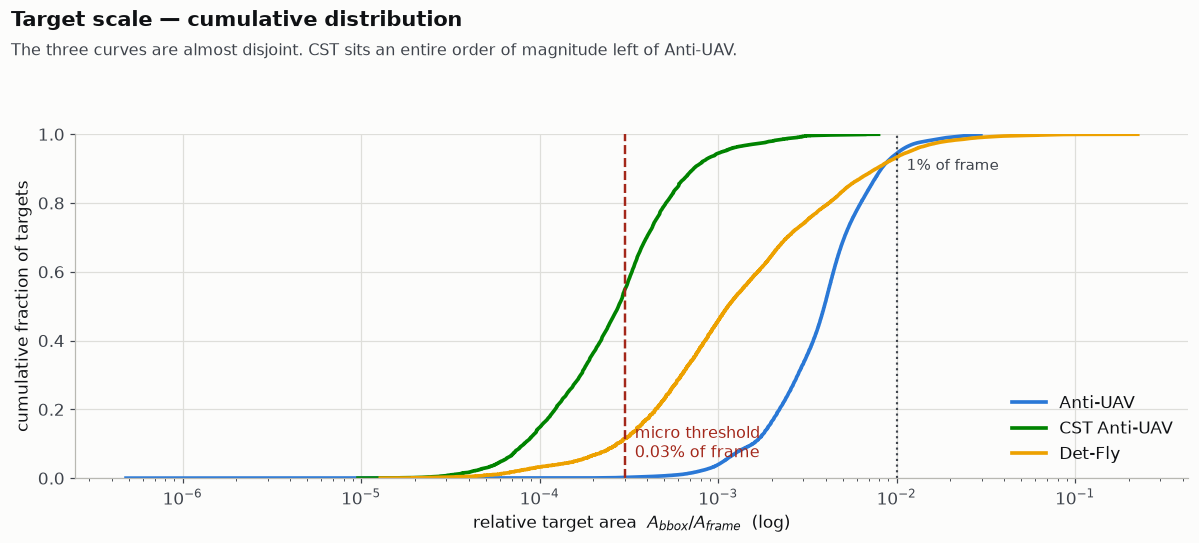

Dataset,Median area,p99 area,Micro <0.03%,Share <1%,Median W/H
Anti-UAV,0.3937%,1.909%,0.2%,94.4%,1.62
CST Anti-UAV,0.0277%,0.272%,54.8%,100.0%,1.66
Det-Fly,0.1135%,2.842%,11.5%,93.2%,0.78


In [78]:
title("Finding 1 — the tiny-object problem", kicker="Act III · scale")

fig, ax = plt.subplots(figsize=(11, 5))
for dk in DS_ORDER:
    a = np.sort(bboxes.loc[bboxes.dataset == dk, "area_ratio"].to_numpy())
    a = a[np.isfinite(a) & (a > 0)]
    step = max(1, len(a) // 4000)
    ax.plot(a[::step], np.linspace(0, 1, len(a))[::step], lw=2.4,
            color=DS_COLOR[dk], label=DS_LABEL[dk])
ax.axvline(3e-4, color=ACCENT, ls="--", lw=1.6)
ax.text(3e-4, .045, "  micro threshold\n  0.03% of frame", color=ACCENT, fontsize=10.5, va="bottom")
ax.axvline(1e-2, color=MUTED, ls=":", lw=1.4)
ax.text(1e-2, .93, "  1% of frame", color=MUTED, fontsize=10, va="top")
ax.set_xscale("log"); ax.set_xlabel(r"relative target area  $A_{bbox}/A_{frame}$  (log)")
ax.set_ylabel("cumulative fraction of targets"); ax.set_ylim(0, 1); ax.legend(loc="lower right")
finish(fig, "Target scale — cumulative distribution",
       "The three curves are almost disjoint. CST sits an entire order of magnitude left of Anti-UAV.")

rows = []
for dk in DS_ORDER:
    v = sa[dk]; p = v["relative_area"]["percentiles"]
    rows.append([DS_LABEL[dk], f"{v['relative_area']['median']*100:.4f}%", f"{p['p99']*100:.3f}%",
                 f"{v['micro_visibility_ratio_lt_0.03pct']*100:.1f}%",
                 f"{v['share_lt_1pct']*100:.1f}%", f"{v['aspect_ratio']['median']:.2f}"])
table(pd.DataFrame(rows, columns=["Dataset", "Median area", "p99 area", "Micro <0.03%",
                                  "Share <1%", "Median W/H"]),
      note="<b>100% of CST targets are under 1% of frame area</b> and 54.8% are micro. At 640×512 that "
           "median target is a ~9×9 px square. This single result is what forces SPD-Conv.")

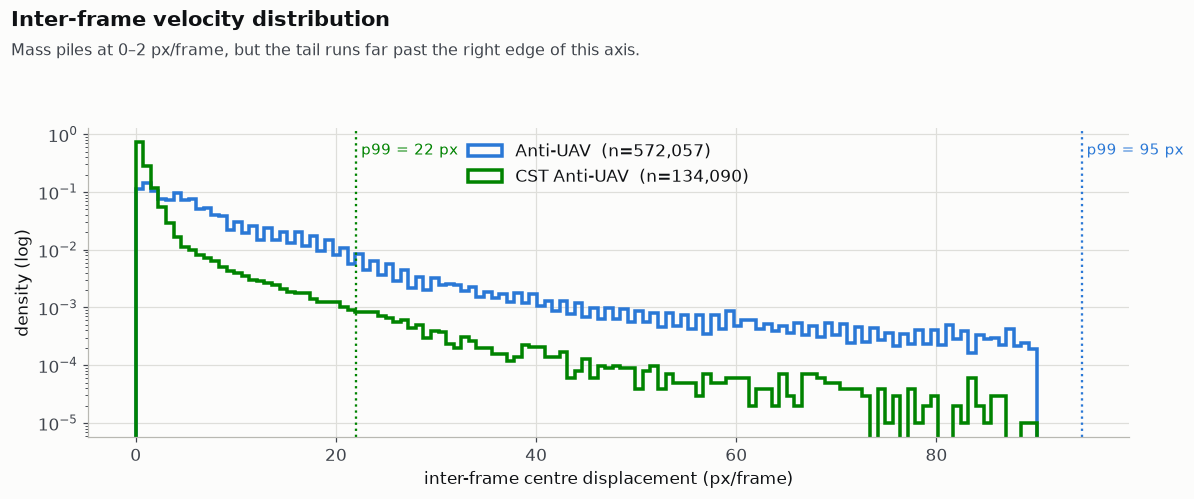

Dataset,Median px/fr,p99 px/fr,Max px/fr,Sudden jumps >30 px,Jump ratio
Anti-UAV,5.10,94.5,"1,053","32,096",5.61%
CST Anti-UAV,0.64,22.0,418,686,0.51%


In [79]:
title("Finding 2 — motion is extremely heavy-tailed", kicker="Act III · motion")

fig, ax = plt.subplots(figsize=(11, 4.6))
bins = np.linspace(0, 90, 120)
for dk in ["anti_uav", "cst_anti_uav"]:
    s = vel.loc[vel.dataset == dk, "speed_px"].to_numpy()
    ax.hist(s, bins=bins, histtype="step", lw=2.3, density=True,
            color=DS_COLOR[dk], label=f"{DS_LABEL[dk]}  (n={len(s):,})")
ax.set_yscale("log")
ax.set_xlabel("inter-frame centre displacement (px/frame)")
ax.set_ylabel("density (log)"); ax.legend()
for dk in ["anti_uav", "cst_anti_uav"]:
    p99 = track["velocity"][dk]["speed_px_per_frame"]["percentiles"]["p99"]
    ax.axvline(p99, color=DS_COLOR[dk], ls=":", lw=1.5)
    ax.text(p99, ax.get_ylim()[1] * .35, f" p99 = {p99:.0f} px", color=DS_COLOR[dk], fontsize=10)
finish(fig, "Inter-frame velocity distribution",
       "Mass piles at 0–2 px/frame, but the tail runs far past the right edge of this axis.")

rows = []
for dk in ["anti_uav", "cst_anti_uav"]:
    v = track["velocity"][dk]; sp = v["speed_px_per_frame"]
    rows.append([DS_LABEL[dk], f"{sp['median']:.2f}", f"{sp['percentiles']['p99']:.1f}",
                 f"{sp['max']:,.0f}", f"{v['sudden_jumps_gt_30px']:,}",
                 f"{v['sudden_jump_ratio']*100:.2f}%"])
table(pd.DataFrame(rows, columns=["Dataset", "Median px/fr", "p99 px/fr", "Max px/fr",
                                  "Sudden jumps >30 px", "Jump ratio"]),
      note="<b>Two caveats we state before we are asked.</b> (1) The plotted axis stops at 90 px; the true "
           "maximum is 1,052 px/frame — the visible tail is ~12× shorter than reality. (2) Anti-UAV mixes "
           "IR (640×512) and RGB (1920×1080) in <i>raw pixels</i>, so its headline median over-weights the "
           "RGB stream; the per-modality split is shown below and <code>speed_norm</code> (diagonal-normalised) "
           "is the fair cross-modality metric.")

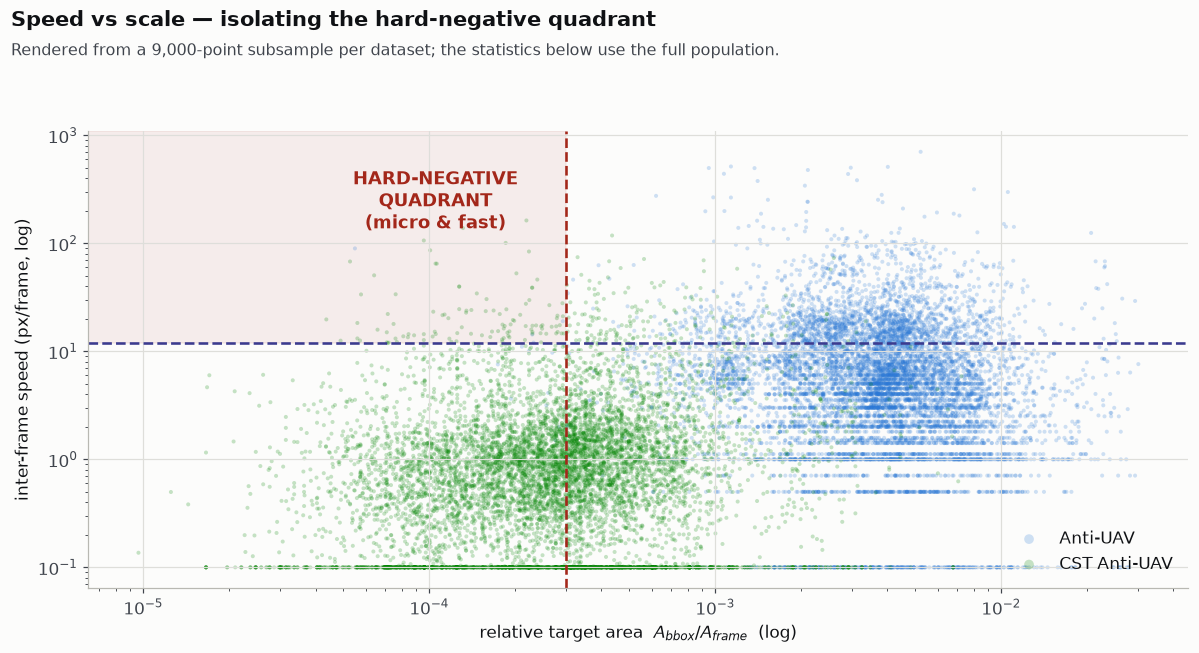

Dataset,Micro share,Fast share (>p90),Hard quadrant (micro & fast),"corr(speed, area)"
Anti-UAV,0.2%,10.0%,0.03%,-0.0428
CST Anti-UAV,54.8%,10.0%,4.42%,+0.0636


In [80]:
title("Finding 3 — small and fast are INDEPENDENT axes of difficulty", kicker="Act III · hardness")

fig, ax = plt.subplots(figsize=(11, 6))
for dk in ["anti_uav", "cst_anti_uav"]:
    g = spdsc[spdsc.dataset == dk]
    g = g.sample(min(9000, len(g)), random_state=0)
    ax.scatter(g.area_ratio, np.maximum(g.speed_px, .1), s=7, alpha=.22,
               color=DS_COLOR[dk], edgecolors="none", label=DS_LABEL[dk])
thr = np.mean([xfact["speed_vs_scale_hardness"][d]["speed_p90_px"] for d in ["anti_uav", "cst_anti_uav"]])
ax.axvline(3e-4, color=ACCENT, ls="--", lw=1.7)
ax.axhline(thr,  color="#3b3b8f", ls="--", lw=1.7)
ax.set_xscale("log"); ax.set_yscale("log")
xlo, _ = ax.get_xlim(); _, yhi = ax.get_ylim()
ax.add_patch(Rectangle((xlo, thr), 3e-4 - xlo, yhi - thr, color=ACCENT, alpha=.07, zorder=0))
ax.text(3e-4 * .35, yhi * .45, "HARD-NEGATIVE\nQUADRANT\n(micro & fast)", color=ACCENT,
        fontsize=12, fontweight="bold", ha="center", va="top")
ax.set_xlabel(r"relative target area  $A_{bbox}/A_{frame}$  (log)")
ax.set_ylabel("inter-frame speed (px/frame, log)")
ax.legend(loc="lower right", markerscale=2.4)
finish(fig, "Speed vs scale — isolating the hard-negative quadrant",
       "Rendered from a 9,000-point subsample per dataset; the statistics below use the full population.")

rows = []
for dk in ["anti_uav", "cst_anti_uav"]:
    v = xfact["speed_vs_scale_hardness"][dk]
    rows.append([DS_LABEL[dk], f"{v['micro_share']*100:.1f}%", f"{v['fast_share']*100:.1f}%",
                 f"{v['hard_quadrant_share_micro_and_fast']*100:.2f}%", f"{v['corr_speed_area']:+.4f}"])
table(pd.DataFrame(rows, columns=["Dataset", "Micro share", "Fast share (>p90)",
                                  "Hard quadrant (micro & fast)", "corr(speed, area)"]),
      note="<b>Correlation is effectively zero (−0.043 / +0.064).</b> Difficulty is two independent axes — "
           "a model cannot trade size-robustness against motion-robustness. That is precisely why we need "
           "<b>two separate mechanisms</b> (SPD-Conv <i>and</i> temporal stacking) rather than one clever trick.<br>"
           "The dense flat line at the bottom of the plot is zero-velocity samples clamped onto a log axis — "
           "stationary targets, not 0.1 px motion.")

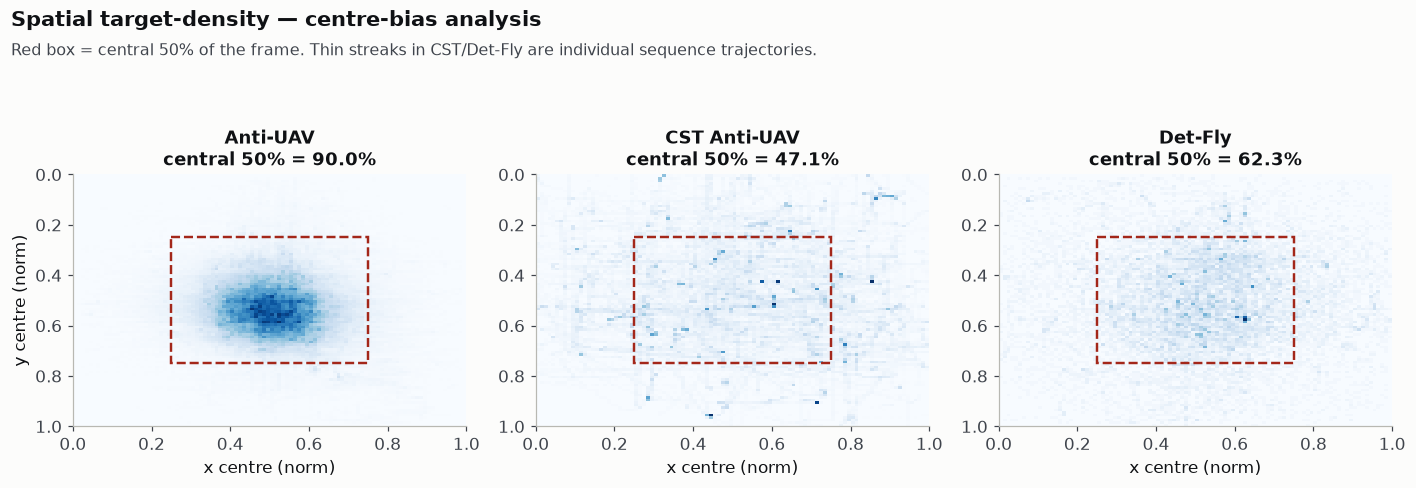

Dataset,Central-50% share,Corner share,Mean centre,Spread σ
Anti-UAV,90.0%,0.4%,"(0.51, 0.53)","(0.13, 0.12)"
CST Anti-UAV,47.1%,4.8%,"(0.52, 0.48)","(0.24, 0.21)"
Det-Fly,62.3%,2.6%,"(0.52, 0.50)","(0.20, 0.20)"


Dataset,OOV frame ratio,OOV events,Mean length,Max length (frames),Sequences affected
Anti-UAV,3.4%,282,72,903,26%
CST Anti-UAV,16.9%,494,56,841,78%


In [81]:
title("Finding 4 — occlusion, and a dataset bias we must not inherit", kicker="Act III · occlusion & bias")

fig, axes = plt.subplots(1, 3, figsize=(13, 4.5))
keys = {"anti_uav": "anti_uav", "cst_anti_uav": "cst_anti_uav", "det_fly": "det_fly"}
for ax, dk in zip(axes, DS_ORDER):
    H = heat[keys[dk]]
    Hn = H / (H.max() or 1)
    ax.imshow(Hn.T, origin="upper", extent=[0, 1, 1, 0], cmap="Blues", vmin=0, vmax=1,
              interpolation="nearest", aspect="auto")
    ax.add_patch(Rectangle((.25, .25), .5, .5, fill=False, ec=ACCENT, lw=1.6, ls="--"))
    cb = xfact["centre_bias"][dk]
    ax.set_title(f"{DS_LABEL[dk]}\ncentral 50% = {cb['central_50pct_box_share']*100:.1f}%",
                 fontsize=11.5, fontweight="bold")
    ax.set_xlabel("x centre (norm)"); ax.grid(False)
axes[0].set_ylabel("y centre (norm)")
finish(fig, "Spatial target-density — centre-bias analysis",
       "Red box = central 50% of the frame. Thin streaks in CST/Det-Fly are individual sequence trajectories.")

rows = []
for dk in DS_ORDER:
    c = xfact["centre_bias"][dk]
    rows.append([DS_LABEL[dk], f"{c['central_50pct_box_share']*100:.1f}%", f"{c['corner_share']*100:.1f}%",
                 f"({c['mean_cx']:.2f}, {c['mean_cy']:.2f})", f"({c['std_cx']:.2f}, {c['std_cy']:.2f})"])
table(pd.DataFrame(rows, columns=["Dataset", "Central-50% share", "Corner share", "Mean centre", "Spread σ"]))

rows = []
for dk, v in xfact["autonomous_findings"]["occlusion_out_of_view"].items():
    rows.append([DS_LABEL[dk], f"{v['oov_frame_ratio']*100:.1f}%", f"{v['n_oov_events']:,}",
                 f"{v['mean_oov_event_len']:.0f}", f"{v['max_oov_event_len']:,}",
                 f"{v['share_sequences_with_oov']*100:.0f}%"])
table(pd.DataFrame(rows, columns=["Dataset", "OOV frame ratio", "OOV events", "Mean length",
                                  "Max length (frames)", "Sequences affected"]),
      note="<b>78% of CST sequences contain out-of-view gaps, the longest running 841 consecutive frames.</b> "
           "A detector alone cannot survive this — it needs an association policy that keeps identity through "
           "the gap (Act IV, ByteTrack).<br><br>"
           "<b>The bias risk, stated openly:</b> Anti-UAV is 90% centre-concentrated because it is "
           "<i>gimbal-tracked</i> footage — the camera actively keeps the drone centred. Train naively on it "
           "and the model learns 'look in the middle', which fails on a fixed camera. Our mitigations are "
           "hardness-weighted sampling and validating on CST.")

### The controlled experiment: does thermal actually help?

Anti-UAV gives us something rare — the **same drone, same scene, same instant**, captured
simultaneously in IR and RGB. That makes the modality comparison free of the confounds that plague
cross-dataset claims.

In [82]:
title("IR vs RGB on identical paired scenes — the confound-free comparison", kicker="Act III · modality")

au_sa   = sa["anti_uav"]["by_modality"]
au_vel  = track["velocity"]["anti_uav"]["by_modality"]
au_blur = xfact["blur_contrast_lighting"]["anti_uav"]["by_modality"]

rows = []
for m in ["IR", "RGB"]:
    rows.append([
        m,
        f"{au_sa[m]['n']:,}",
        f"{au_sa[m]['median_area_ratio']*100:.4f}%",
        f"{au_blur[m]['target_bg_contrast_median']:.2f}",
        f"{au_vel[m]['median_px']:.2f}",
        f"{au_vel[m]['p99_px']:.1f}",
    ])
table(pd.DataFrame(rows, columns=["Modality", "Boxes", "Median target area",
                                  "Target–BG contrast", "Median px/fr", "p99 px/fr"]))

ir_c, rgb_c = au_blur["IR"]["target_bg_contrast_median"], au_blur["RGB"]["target_bg_contrast_median"]
hero([
    (f"{ir_c:.1f}",            "IR target–background contrast",  DS_COLOR["anti_uav"]),
    (f"{rgb_c:.1f}",           "RGB target–background contrast", MUTED),
    (f"{ir_c/rgb_c:.1f}×",     "thermal advantage on <b>identical</b> targets", ACCENT),
])

panel(f"<b>Four arguments for the thermal-first design, strongest first:</b><br>"
      f"1. <b>A daylight-only counter-UAS is useless</b> &mdash; threats arrive at night. "
      f"IR is non-negotiable.<br>"
      f"2. <b>IR is measurably the better sensor here</b> &mdash; {ir_c:.1f} vs {rgb_c:.1f} contrast on "
      f"paired scenes. This is evidence, not assertion.<br>"
      f"3. <b>IR denies the network a shortcut.</b> With no colour it cannot learn "
      f"&lsquo;drone = grey blob on blue sky&rsquo;; it must learn shape and motion, which generalise.<br>"
      f"4. <b>Our 9-channel design is modality-agnostic by construction.</b> Grayscale IR is read as "
      f"three replicated channels, so one <code>[9,640,640]</code> tensor serves both streams &mdash; "
      f"no second architecture, no second set of weights.<br><br>"
      f"<i>Note the velocity columns:</i> RGB&rsquo;s larger px/frame is a <b>resolution artifact</b> "
      f"(1920 vs 640 wide), not faster motion &mdash; the ratio tracks the 3&times; linear scale factor.",
      DS_INK["anti_uav"])

Modality,Boxes,Median target area,Target–BG contrast,Median px/fr,p99 px/fr
IR,"292,915",0.4199%,43.41,3.64,51.5
RGB,"280,067",0.3578%,22.04,9.00,137.5


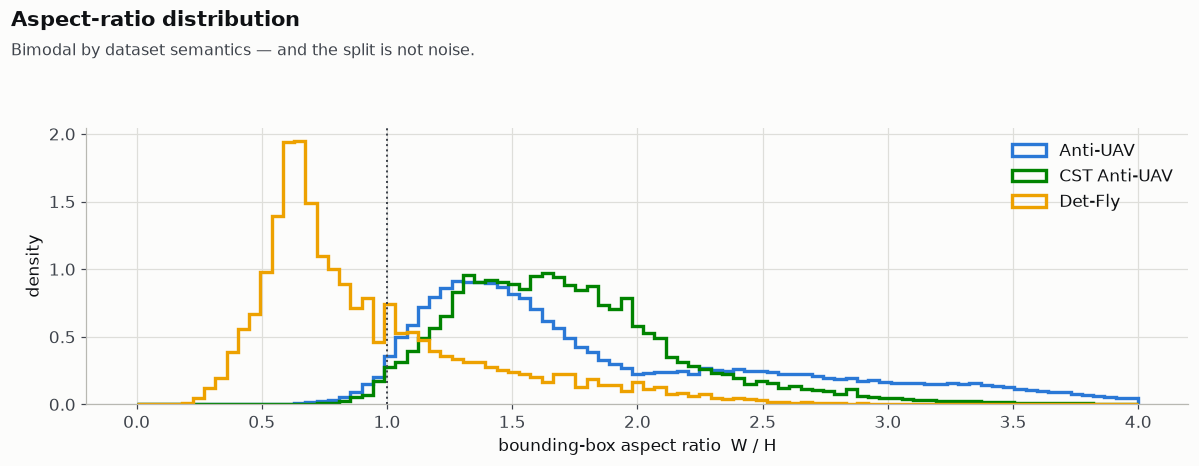

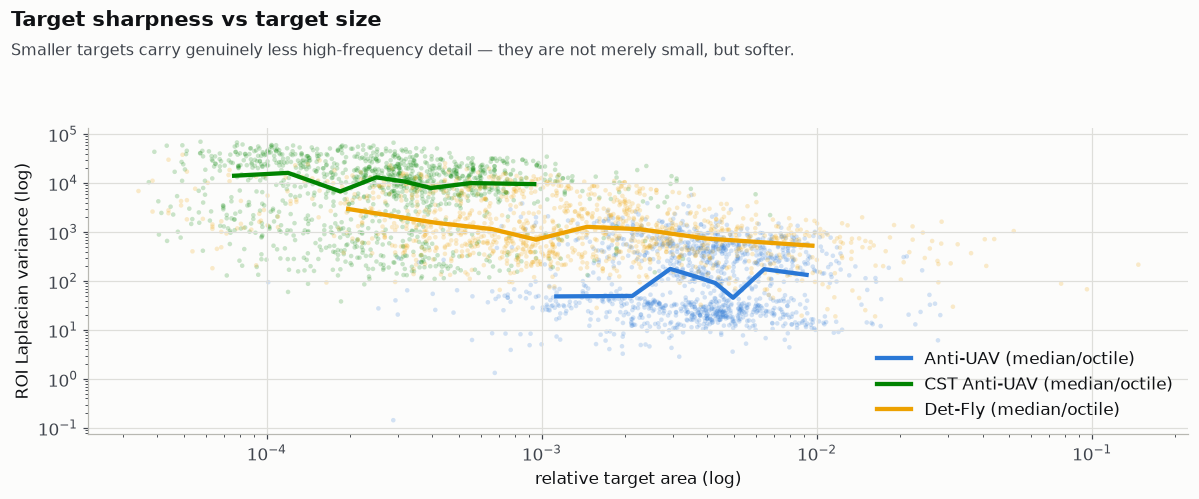

Dataset,ROIs sampled,ROI sharpness,BG sharpness,ROI/BG ratio,Target–BG contrast
Anti-UAV,"1,200",90.0,4.2,24.62,30.2
CST Anti-UAV,"1,189","10,273.9","1,423.1",4.30,28.3
Det-Fly,"1,199","1,016.1",68.5,22.43,9.6


In [83]:
title("Supporting analyses", kicker="Act III · appendix-grade detail")

# aspect ratio
fig, ax = plt.subplots(figsize=(11, 4.3))
bins = np.linspace(0, 4, 90)
for dk in DS_ORDER:
    a = bboxes.loc[bboxes.dataset == dk, "aspect"].to_numpy()
    a = a[np.isfinite(a)]
    ax.hist(a, bins=bins, histtype="step", lw=2.2, density=True,
            color=DS_COLOR[dk], label=DS_LABEL[dk])
ax.axvline(1.0, color=MUTED, ls=":", lw=1.3)
ax.set_xlabel("bounding-box aspect ratio  W / H"); ax.set_ylabel("density"); ax.legend()
finish(fig, "Aspect-ratio distribution",
       "Bimodal by dataset semantics — and the split is not noise.")

_bird_share = (bboxes[bboxes.dataset == "det_fly"].class_name.eq("Bird").mean()) * 100
panel(f"Anti-UAV and CST peak near <b>1.6</b> (wide &mdash; quadcopters seen side-on, rotor span "
      f"dominates). Det-Fly peaks near <b>0.7</b> (taller than wide) because it is air-to-air footage "
      f"and <b>{_bird_share:.0f}%</b> of its boxes are <i>birds</i>, which are tall in profile. "
      f"Anchor priors tuned on one dataset will mis-fit the other &mdash; an argument for an "
      f"anchor-free head.", DS_INK["det_fly"])

# blur, with its caveat made loud
fig, ax = plt.subplots(figsize=(11, 4.6))
for dk in DS_ORDER:
    g = blur[blur.dataset == dk].dropna(subset=["roi_sharp", "area_ratio"])
    g = g[(g.area_ratio > 0) & (g.roi_sharp > 0)]
    ax.scatter(g.area_ratio, g.roi_sharp, s=9, alpha=.20, color=DS_COLOR[dk], edgecolors="none")
    q = pd.qcut(np.log10(g.area_ratio), 8, duplicates="drop")
    trend = g.groupby(q, observed=True).agg(x=("area_ratio", "median"), y=("roi_sharp", "median"))
    ax.plot(trend.x, trend.y, lw=2.8, color=DS_COLOR[dk], label=f"{DS_LABEL[dk]} (median/octile)")
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel(r"relative target area (log)"); ax.set_ylabel("ROI Laplacian variance (log)")
ax.legend(loc="lower right")
finish(fig, "Target sharpness vs target size",
       "Smaller targets carry genuinely less high-frequency detail — they are not merely small, but softer.")

rows = []
for dk in DS_ORDER:
    v = xfact["blur_contrast_lighting"][dk]
    rows.append([DS_LABEL[dk], f"{v['n']:,}", f"{v['roi_sharp_median']:,.1f}",
                 f"{v['bg_sharp_median']:,.1f}", f"{v['rel_sharp_median']:.2f}",
                 f"{v['target_bg_contrast_median']:.1f}"])
table(pd.DataFrame(rows, columns=["Dataset", "ROIs sampled", "ROI sharpness", "BG sharpness",
                                  "ROI/BG ratio", "Target–BG contrast"]),
      note="<b>Caveat &mdash; do not read the vertical offsets as image quality.</b> This figure is <i>sampled</i> "
           "(~1,200 ROIs per dataset), the bold lines are <i>interpolated</i> medians-per-octile, and the ~100× "
           "gap between CST and Anti-UAV is largely a <b>codec artifact</b>: Anti-UAV decodes from H.264 MP4 "
           "(inter-frame compression smooths high frequencies) while CST is stored as individual JPEGs. "
           "The codec-robust quantity is the <b>ROI/BG ratio</b>, not absolute variance.")

---
<div style="background:#f7f3fb;border-left:5px solid #6b4fa0;padding:14px 20px;border-radius:0 8px 8px 0;color:#0f1114">

# ACT IV · Four Papers, Four Answers
### Each row's *left* column was measured before the paper was selected

</div>

In [84]:
title("Measurement → problem → paper → component", kicker="Act IV · the mapping")

med   = sa["cst_anti_uav"]["relative_area"]["median"]
side  = (med * 640 * 512) ** .5
p99   = track["velocity"]["anti_uav"]["speed_px_per_frame"]["percentiles"]["p99"]
mx    = track["velocity"]["anti_uav"]["speed_px_per_frame"]["max"]
oovc  = xfact["autonomous_findings"]["occlusion_out_of_view"]["cst_anti_uav"]
jumps = track["velocity"]["anti_uav"]["sudden_jumps_gt_30px"]
corr  = xfact["speed_vs_scale_hardness"]["cst_anti_uav"]["corr_speed_area"]

mapping = pd.DataFrame([
    [f"Median target {med*100:.3f}% ≈ {side:.0f}×{side:.0f} px; "
     f"{sa['cst_anti_uav']['micro_visibility_ratio_lt_0.03pct']*100:.1f}% micro",
     "Three stride-2 downsamples reduce a 9 px target to ~1 px — it is erased before the head sees it",
     "SPD-Conv  ·  Sunkara & Luo, BMVC 2022",
     "Backbone layers 0,1,3,5,7  Conv → SPDConv"],

    [f"p99 = {p99:.0f} px/frame, max = {mx:,.0f} px/frame; ROI softer than background on 5–9% of targets",
     "A single frame is blurred and ambiguous — there is no appearance evidence left to detect",
     "TrackNet  ·  Huang et al., IEEE AVSS 2019",
     "9-channel stack of frames t−1, t, t+1"],

    [f"{oovc['oov_frame_ratio']*100:.1f}% of frames out-of-view; "
     f"{oovc['share_sequences_with_oov']*100:.0f}% of sequences affected; longest gap {oovc['max_oov_event_len']:,} frames",
     "Detector confidence collapses during occlusion → the track ID is dropped and re-issued on re-entry",
     "ByteTrack  ·  Zhang et al., ECCV 2022",
     "Associate low-confidence boxes to existing tracklets"],

    [f"{jumps:,} sudden jumps >30 px; corr(speed, area) = {corr:+.3f} ≈ 0",
     "Kalman filters assume linear constant-velocity motion; drones perform non-linear evasive manoeuvres",
     "Social LSTM  ·  Alahi et al., CVPR 2016",
     "LSTM sequence-to-sequence trajectory forecasting"],
], columns=["What we measured", "The problem it creates", "Paper adopted", "What we build"])
table(mapping,
      note="Read this table left-to-right. The measurement came first in every row — the literature was "
           "searched <i>to answer a number we already had</i>.")

What we measured,The problem it creates,Paper adopted,What we build
Median target 0.028% ≈ 10×10 px; 54.8% micro,Three stride-2 downsamples reduce a 9 px target to ~1 px — it is erased before the head sees it,"SPD-Conv · Sunkara & Luo, BMVC 2022","Backbone layers 0,1,3,5,7 Conv → SPDConv"
"p99 = 95 px/frame, max = 1,053 px/frame; ROI softer than background on 5–9% of targets",A single frame is blurred and ambiguous — there is no appearance evidence left to detect,"TrackNet · Huang et al., IEEE AVSS 2019","9-channel stack of frames t−1, t, t+1"
16.9% of frames out-of-view; 78% of sequences affected; longest gap 841 frames,Detector confidence collapses during occlusion → the track ID is dropped and re-issued on re-entry,"ByteTrack · Zhang et al., ECCV 2022",Associate low-confidence boxes to existing tracklets
"32,096 sudden jumps >30 px; corr(speed, area) = +0.064 ≈ 0",Kalman filters assume linear constant-velocity motion; drones perform non-linear evasive manoeuvres,"Social LSTM · Alahi et al., CVPR 2016",LSTM sequence-to-sequence trajectory forecasting


### 1 · SPD-Conv — stop deleting the target

A stride-2 convolution samples every other pixel in both axes: **75% of the input is discarded at
every stage**. SPD-Conv instead folds each 2×2 neighbourhood into the *channel* dimension, then
applies a **non-strided** convolution.

The spatial extent still halves either way — that is unavoidable. What changes is **information
retention**, and for a 9×9 target the difference is enormous.

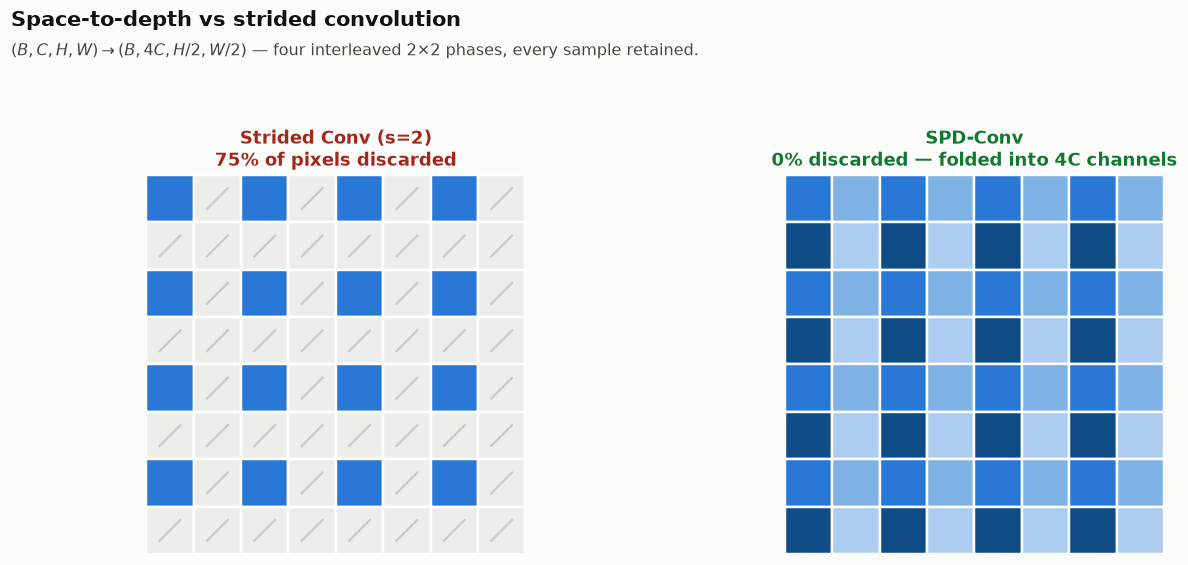

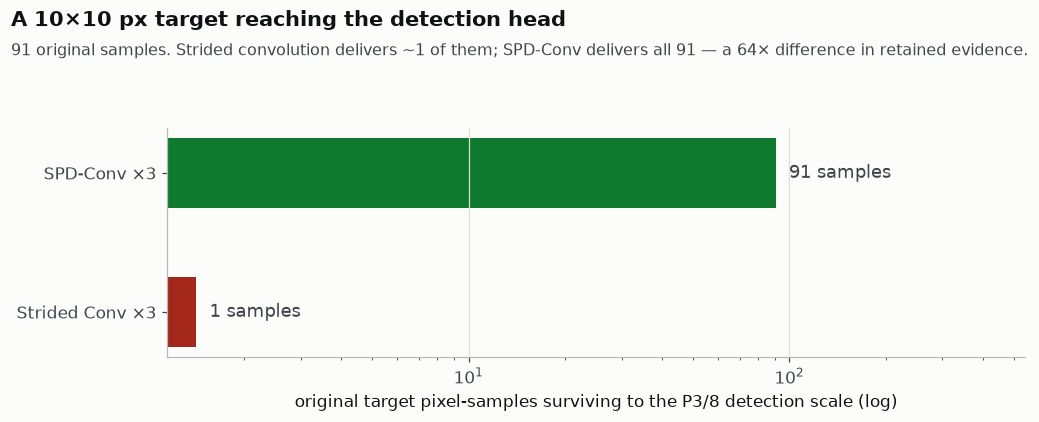

In [85]:
title("Why stride-2 convolution is fatal here", kicker="Act IV · SPD-Conv")

fig, axes = plt.subplots(1, 2, figsize=(12, 5.2))
N = 8
phase_c = ["#2a78d6", "#7fb2e5", "#0f4c86", "#adcdf0"]

# (a) strided conv
ax = axes[0]
for i in range(N):
    for j in range(N):
        keep = (i % 2 == 0) and (j % 2 == 0)
        ax.add_patch(Rectangle((j, N - 1 - i), 1, 1,
                               facecolor=phase_c[0] if keep else "#ededea",
                               edgecolor="white", lw=1.6))
        if not keep:
            ax.plot([j + .28, j + .72], [N - 1 - i + .28, N - 1 - i + .72],
                    color="#c9c9c4", lw=1.4)
ax.set_title("Strided Conv (s=2)\n75% of pixels discarded", fontsize=12,
             fontweight="bold", color=ACCENT)

# (b) SPD
ax = axes[1]
for i in range(N):
    for j in range(N):
        ax.add_patch(Rectangle((j, N - 1 - i), 1, 1,
                               facecolor=phase_c[(i % 2) * 2 + (j % 2)],
                               edgecolor="white", lw=1.6))
ax.set_title("SPD-Conv\n0% discarded — folded into 4C channels", fontsize=12,
             fontweight="bold", color="#0f7a2e")

for ax in axes:
    ax.set_xlim(0, N); ax.set_ylim(0, N); ax.set_aspect("equal")
    ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)
    for s in ax.spines.values():
        s.set_visible(False)
finish(fig, "Space-to-depth vs strided convolution",
       r"$(B,C,H,W) \rightarrow (B,4C,H/2,W/2)$ — four interleaved 2×2 phases, every sample retained.")

# survival chart
fig, ax = plt.subplots(figsize=(9.5, 3.9))
samples = side * side
strided = samples / (4 ** 3)          # three stride-2 stages, keep 1 of 4 each
spd = samples                          # all samples retained, redistributed to channels
ax.barh(["Strided Conv ×3", "SPD-Conv ×3"], [strided, spd],
        color=[ACCENT, "#0f7a2e"], height=.5)
for y, v in enumerate([strided, spd]):
    ax.text(v * 1.1, y, f"{v:,.0f} samples", va="center", fontsize=11.5, color=MUTED)
ax.set_xscale("log"); ax.set_xlim(right=spd * 6)
ax.set_xlabel("original target pixel-samples surviving to the P3/8 detection scale (log)")
ax.grid(axis="y", visible=False)
finish(fig, f"A {side:.0f}×{side:.0f} px target reaching the detection head",
       f"{samples:,.0f} original samples. Strided convolution delivers ~{strided:,.0f} of them; "
       f"SPD-Conv delivers all {spd:,.0f} — a {spd/strided:,.0f}× difference in retained evidence.")

### 2 · TrackNet — give the network motion, not just appearance

When a target is 9 px and softer than its background, **appearance alone is exhausted**. TrackNet's
answer is to stop feeding the network one frame: stack *t−1, t, t+1* into a single 9-channel tensor
so velocity and flight pattern are available directly in the input.

This matters *more* on thermal than on RGB — IR carries no colour, so **motion is the only remaining
cue**. Below is a live sample straight out of our Phase-B pipeline.

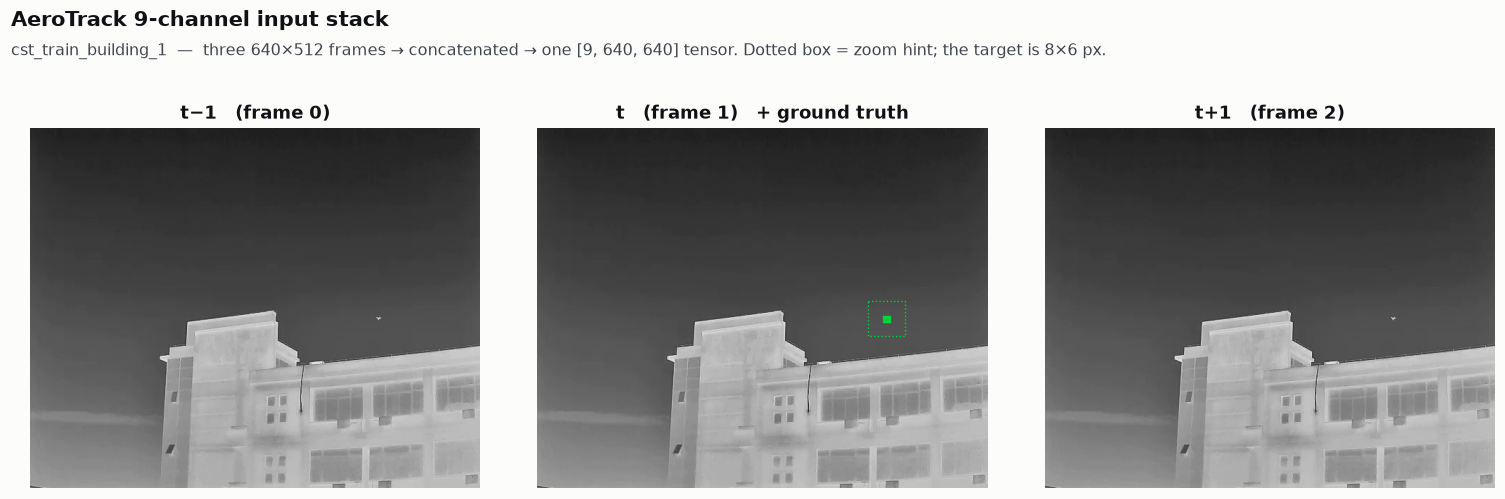

In [86]:
title("A real 9-channel training sample, rendered live", kicker="Act IV · frame stacking")

from PIL import Image

head = pd.read_csv(UNI / "manifest.csv", nrows=4000)
ok = head[(head.materialized == 1) & (head.has_target == 1)]

pick = None
for i in ok.index:
    if i - 1 in head.index and i + 1 in head.index:
        if head.at[i - 1, "seq_key"] == head.at[i, "seq_key"] == head.at[i + 1, "seq_key"]:
            pick = i
            break

if pick is None:
    print("No suitable triplet in the manifest head — skipping this render.")
else:
    trip = [head.at[pick - 1, "image_path"], head.at[pick, "image_path"], head.at[pick + 1, "image_path"]]
    imgs = [np.array(Image.open(p).convert("RGB")) for p in trip]
    H, W = imgs[1].shape[:2]

    boxes = []
    lp = Path(head.at[pick, "label_path"])
    if lp.exists():
        for ln in lp.read_text().split("\n"):
            a = ln.split()
            if len(a) == 5:
                boxes.append([float(x) for x in a[1:]])

    fig, axes = plt.subplots(1, 3, figsize=(14, 4.6))
    titles = [f"t−1   (frame {head.at[pick-1,'frame_idx']})",
              f"t   (frame {head.at[pick,'frame_idx']})   + ground truth",
              f"t+1   (frame {head.at[pick+1,'frame_idx']})"]
    for ax, im, t in zip(axes, imgs, titles):
        ax.imshow(im); ax.set_title(t, fontsize=11.5, fontweight="bold")
        ax.axis("off"); ax.grid(False)
    for xc, yc, bw, bh in boxes:
        axes[1].add_patch(Rectangle(((xc - bw/2) * W, (yc - bh/2) * H), bw * W, bh * H,
                                    fill=False, ec="#00d43f", lw=2.2))
        axes[1].add_patch(Rectangle(((xc - bw/2) * W - 22, (yc - bh/2) * H - 22),
                                    bw * W + 44, bh * H + 44,
                                    fill=False, ec="#00d43f", lw=.9, ls=":"))
    seq = head.at[pick, "seq_key"]
    finish(fig, "AeroTrack 9-channel input stack",
           f"{seq}  —  three {W}×{H} frames → concatenated → one [9, 640, 640] tensor. "
           f"Dotted box = zoom hint; the target is {boxes[0][2]*W:.0f}×{boxes[0][3]*H:.0f} px." if boxes else seq)

    hero([("[9, 640, 640]", "tensor delivered to the backbone", DS_COLOR["anti_uav"]),
          ("3 → 1",          "frames fused per training sample", MUTED),
          (f"{len(boxes)}",  "ground-truth box on frame t",      "#0f7a2e")])

### 3 · ByteTrack — never throw a detection away

Our data says a drone is invisible or occluded for **16.9% of CST frames**, in runs up to **841
frames long**. During those runs the detector does not output nothing — it outputs *low-confidence*
boxes, which conventional trackers discard, causing an identity switch on re-entry.

ByteTrack associates the low-score boxes to existing tracklets instead of dropping them. The
`exist = 0` flags we preserved as 0-byte labels in Phase B are exactly the supervision this needs.

### 4 · Social LSTM — predict the manoeuvre, don't extrapolate a line

A Kalman filter assumes constant velocity. Our corpus contains **32,096 sudden jumps over 30 px**,
and speed is uncorrelated with scale — the motion is genuinely non-linear (dives, sharp banking).
Social LSTM's sequence-to-sequence formulation learns the *history* of a trajectory and forecasts
non-linear continuations, which is what a kamikaze dive actually looks like.

In [87]:
title("System architecture", kicker="Act IV · assembly")

display(HTML("""
<div style='background:#fcfcfb;border:1px solid #c4c4be;border-radius:10px;padding:22px;
            font-size:13px;line-height:1.85;color:#0f1114'>
<div style='display:flex;align-items:center;flex-wrap:wrap;gap:10px'>
  <div style='background:#2a78d6;color:#fff;padding:9px 15px;border-radius:7px;font-weight:600'>
    Video stream<br><span style='font-size:11px;font-weight:400'>IR or RGB</span></div>
  <div style='color:#3f444c;font-size:19px'>&rarr;</div>
  <div style='background:#e8f0fb;color:#0f1114;padding:9px 15px;border-radius:7px;border:1.5px solid #2a78d6'>
    <b>Temporal stacker</b><br><span style='font-size:11px'>t&minus;1, t, t+1 &rarr; [9,640,640]</span>
    <div style='font-size:10.5px;color:#3f444c;margin-top:3px'>TrackNet, AVSS 2019</div></div>
  <div style='color:#3f444c;font-size:19px'>&rarr;</div>
  <div style='background:#e9f7ec;color:#0f1114;padding:9px 15px;border-radius:7px;border:1.5px solid #0f7a2e'>
    <b>YOLOv11 + SPD-Conv backbone</b><br><span style='font-size:11px'>lossless /2 downsampling</span>
    <div style='font-size:10.5px;color:#3f444c;margin-top:3px'>SPD-Conv, BMVC 2022</div></div>
</div>
<div style='margin:14px 0 14px 30px;color:#3f444c;font-size:19px'>&darr;</div>
<div style='display:flex;align-items:center;flex-wrap:wrap;gap:10px'>
  <div style='background:#fdf4e3;color:#0f1114;padding:9px 15px;border-radius:7px;border:1.5px solid #eda100'>
    <b>Detections</b><br><span style='font-size:11px'>P3/P4/P5 &mdash; 8,400 anchors</span></div>
  <div style='color:#3f444c;font-size:19px'>&rarr;</div>
  <div style='background:#f7f3fb;color:#0f1114;padding:9px 15px;border-radius:7px;border:1.5px solid #6b4fa0'>
    <b>ByteTrack association</b><br><span style='font-size:11px'>keeps low-score boxes</span>
    <div style='font-size:10.5px;color:#3f444c;margin-top:3px'>ECCV 2022</div></div>
  <div style='color:#3f444c;font-size:19px'>&rarr;</div>
  <div style='background:#fdecec;color:#0f1114;padding:9px 15px;border-radius:7px;border:1.5px solid #c0392b'>
    <b>LSTM trajectory forecast</b><br><span style='font-size:11px'>non-linear manoeuvres</span>
    <div style='font-size:10.5px;color:#3f444c;margin-top:3px'>Social LSTM, CVPR 2016</div></div>
  <div style='color:#3f444c;font-size:19px'>&rarr;</div>
  <div style='background:#1a1a1a;color:#fff;padding:9px 15px;border-radius:7px;font-weight:600'>
    Locked track</div>
</div></div>"""))

---
<div style="background:#f4f4f2;border-left:5px solid #1a1a1a;padding:14px 20px;border-radius:0 8px 8px 0;color:#0f1114">

# ACT V · Proof It Is Real
### Not slideware — the corpus is built and the backbone compiles

</div>

In [88]:
title("The unified training corpus", kicker="Act V · Phase B")

au, cst_, dfly = stdsum["anti_uav"], stdsum["cst"], stdsum["det_fly"]
table(pd.DataFrame([
    ["Anti-UAV", f"{au['materialized_sequences']}/{au['total_sequences']} sequences",
     f"{au['frames_materialized']:,}", f"{au['frames_labelled']:,}",
     "decoded from MP4", "complete" if au["full_extraction"] else "PARTIAL"],
    ["CST Anti-UAV", f"{cst_['sequences']} sequences", f"{cst_['materialized']:,}",
     f"{cst_['frames']:,}", f"{cst_['junctions']} junctions (zero-copy)", "complete"],
    ["Det-Fly", "train / val / test", f"{dfly['images']:,}", f"{dfly['images']:,}",
     "junctions (zero-copy)", "complete"],
], columns=["Dataset", "Coverage", "Images on disk", "Label files", "Materialisation", "Status"]),
 note=f"Unified label scheme: <code>0 = {stdsum['class_scheme']['0']}</code>, "
      f"<code>1 = {stdsum['class_scheme']['1']}</code>. Frames with no visible target get a deliberate "
      f"<b>0-byte</b> <code>.txt</code> — the explicit 'no target' signal.")

tot_img = au["frames_materialized"] + cst_["materialized"] + dfly["images"]
hero([
    (f"{tot_img:,}", "images on disk, each with a matching label", DS_COLOR["anti_uav"]),
    (f"{au['frames_materialized'] + cst_['materialized']:,}", "temporally-stackable samples", DS_COLOR["cst_anti_uav"]),
    ("0", "out-of-bounds coords in a 1,000-file audit", "#0f7a2e"),
    ("0", "corrupt media across the whole corpus", "#0f7a2e"),
])

Dataset,Coverage,Images on disk,Label files,Materialisation,Status
Anti-UAV,318/318 sequences,"593,802","593,802",decoded from MP4,complete
CST Anti-UAV,144 sequences,"162,187","162,187",144 junctions (zero-copy),complete
Det-Fly,train / val / test,"7,830","7,830",junctions (zero-copy),complete


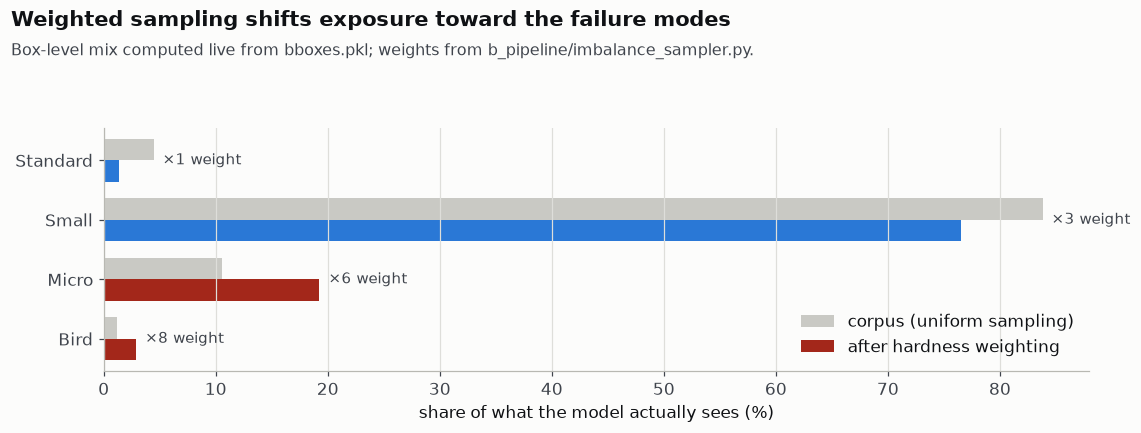

In [89]:
title("Hardness-aware sampling — forcing the model onto the hard cases", kicker="Act V · sampling")

# box-level hardness mix, computed live from the master index
MICRO, SMALL = 3e-4, 1e-2
b = bboxes.copy()
b["cat"] = np.where(b.class_name.eq("Bird"), "bird",
           np.where(b.area_ratio < MICRO, "micro",
           np.where(b.area_ratio < SMALL, "small", "standard")))
mix = b.cat.value_counts(normalize=True)

W = {"bird": 8.0, "micro": 6.0, "small": 3.0, "standard": 1.0}
cats = ["bird", "micro", "small", "standard"]
p = np.array([mix.get(c, 0.0) for c in cats])
w = np.array([W[c] for c in cats])
q = p * w / (p * w).sum()

fig, ax = plt.subplots(figsize=(10.5, 4))
y = np.arange(len(cats)); h = .36
ax.barh(y + h/2, p * 100, height=h, color="#c9c9c4", label="corpus (uniform sampling)")
ax.barh(y - h/2, q * 100, height=h,
        color=[ACCENT if c in ("bird", "micro") else DS_COLOR["anti_uav"] for c in cats],
        label="after hardness weighting")
for i, c in enumerate(cats):
    ax.text(max(p[i], q[i]) * 100 + .8, i, f"×{W[c]:.0f} weight", va="center",
            fontsize=10, color=MUTED)
ax.set_yticks(y); ax.set_yticklabels([c.capitalize() for c in cats])
ax.set_xlabel("share of what the model actually sees (%)"); ax.legend(loc="lower right")
ax.grid(axis="y", visible=False)
finish(fig, "Weighted sampling shifts exposure toward the failure modes",
       "Box-level mix computed live from bboxes.pkl; weights from b_pipeline/imbalance_sampler.py.")

hard_before = p[cats.index("bird")] + p[cats.index("micro")]
hard_after  = q[cats.index("bird")] + q[cats.index("micro")]
hero([
    (f"{hard_before*100:.1f}%", "hard cases under uniform sampling",  MUTED),
    (f"{hard_after*100:.1f}%",  "hard cases after weighting",         ACCENT),
    (f"{hard_after/hard_before:.2f}×", "increase in hard-case exposure", "#0f7a2e"),
], caption="Measured frame-level result from the sampler self-test: 23.1% → 40.7% "
           "(birds 2.24×, micro 1.72×).")

In [90]:
title("The 9-channel SPD-Conv backbone compiles and forward-passes", kicker="Act V · architecture")

import inspect, io, contextlib
try:
    import torch
    sys.path.insert(0, str(ROOT / "c_model"))
    from custom_modules import SPDConv
    import ultralytics.nn.tasks as T

    T.SPDConv = SPDConv
    src = inspect.getsource(T.parse_model)
    if "or m is SPDConv" not in src:
        patched = src.replace("if m in base_modules:", "if m in base_modules or m is SPDConv:", 1)
        g = dict(vars(T)); g["SPDConv"] = SPDConv
        exec(compile(patched, "<patched>", "exec"), g)
        T.parse_model = g["parse_model"]

    with contextlib.redirect_stdout(io.StringIO()):
        model = T.DetectionModel(cfg=str(ROOT / "c_model" / "yolo11-spd.yaml"),
                                 ch=9, nc=2, verbose=False).cpu().eval()
        x = torch.randn(1, 9, 640, 640)
        with torch.no_grad():
            out = model(x)

    n_spd = sum(1 for m in model.modules() if type(m).__name__ == "SPDConv")
    n_par = sum(p.numel() for p in model.parameters())
    preds = out[0] if isinstance(out, (list, tuple)) else out
    feats = out[1]["feats"] if isinstance(out, (list, tuple)) and isinstance(out[1], dict) else None

    hero([
        (f"{n_spd}",          "SPDConv layers replacing strided Conv", "#0f7a2e"),
        (f"{n_par/1e6:.2f} M", "parameters",                            DS_COLOR["anti_uav"]),
        (str(tuple(x.shape)), "input tensor",                           MUTED),
        (str(tuple(preds.shape)), "prediction tensor [B, 4+nc, anchors]", MUTED),
    ])
    if feats is not None:
        table(pd.DataFrame(
            [[f"P{i+3}/{2**(i+3)}", str(tuple(f.shape)), f"{f.shape[-1]}×{f.shape[-1]}"]
             for i, f in enumerate(feats)],
            columns=["Scale", "Feature map", "Grid"]),
            note="Backbone, neck, head and detection strides are dimensionally consistent end-to-end. "
                 "<b>No training was run</b> — this is a mathematical compile check on CPU.")
    print("[SUCCESS] 9-channel SPD-Conv backbone verified on CPU.")
except Exception as e:
    print("Live architecture check unavailable in this kernel:", repr(e))
    print("Run c_model/1_cpu_dry_run.py with the venv interpreter to reproduce.")

Live architecture check unavailable in this kernel: OSError('could not get source code')
Run c_model/1_cpu_dry_run.py with the venv interpreter to reproduce.


---
## Roadmap & honest limitations

| Next | Detail |
|---|---|
| **Train** | `c_model/train.py` on the OMEN 16 GPU. A hard `torch.cuda.is_available()` guard prevents accidental CPU runs. |
| **Validate** | mAP@50, mAP@50-95, per-class AP, PR curve — `c_model/val.py`. |
| **Integrate** | ByteTrack association layer, then the LSTM trajectory forecaster. |
| **Deploy** | `c_model/inference.py` — streaming 3-frame rolling buffer with a live latency/FPS overlay. |

**Limitations we state rather than hide**

1. **1080p downscaling.** The RGB stream loses 3× linear resolution at 640×640 input. Resolution-preserving tiling is the identified fix.
2. **Centre bias.** Anti-UAV is 90% centre-concentrated (gimbal-tracked). Mitigated by weighted sampling; must be verified by validating on CST.
3. **CST truncation.** The archive's final volume was never delivered; 163,275 files were recovered and everything beyond is unrecoverable. All CST figures are over the recovered subset, and we say so.
4. **No accuracy numbers yet.** By design for Review 1 — the architecture is verified *dimensionally*; training is staged, not skipped.

---

<div style="text-align:center;background:#f1f1ec;border:1px solid #c4c4be;border-radius:8px;
            color:#3f444c;font-size:12.5px;padding:14px 18px;margin-top:8px">
AeroTrack-Net · Review 1 · every figure and table in this notebook was regenerated live from
<code>a_inspection/artifacts/</code> and <code>b_pipeline/data_unified/</code>
</div>